### Imports

In [1]:
# train.csv
! gdown 19gyTA8S9wXPlxkyU0mZ_raJO62ny-vpo

# test.csv
! gdown 1NqChJSt70NvgInNvYEyh2GTsBfpXUNuj

# Download dataset
! gdown 1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI

# Unzip
! tar -xzf "CrisisMMD_v2.0.tar.gz"

Downloading...
From: https://drive.google.com/uc?id=19gyTA8S9wXPlxkyU0mZ_raJO62ny-vpo
To: /content/train.csv
100% 988k/988k [00:00<00:00, 9.22MB/s]
Downloading...
From: https://drive.google.com/uc?id=1NqChJSt70NvgInNvYEyh2GTsBfpXUNuj
To: /content/test.csv
100% 421k/421k [00:00<00:00, 7.58MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI
From (redirected): https://drive.google.com/uc?id=1wi_kAVETQHQyGA-thBhP7VY1L2jD5quI&confirm=t&uuid=bd8a039b-fd7f-4a40-9a4f-360432e7efc3
To: /content/CrisisMMD_v2.0.tar.gz
100% 1.90G/1.90G [00:31<00:00, 59.5MB/s]


In [2]:
from google.colab import drive
from pathlib import Path
import os, sys

drive.mount('/content/drive')

DRIVE_CKPT    = Path('/content/drive/MyDrive/checkpoints')
TEXT_CKPT_DIR = DRIVE_CKPT / 'text_branch'       # saved by notebook 01
VISION_CKPT   = DRIVE_CKPT / 'vision_brain.pth'  # saved by notebook 02
FUSION_CKPT   = DRIVE_CKPT / 'fusion_brain.pth'
DRIVE_CKPT.mkdir(parents=True, exist_ok=True)

if not os.path.exists('/content/Data-Science-Project'):
    !git clone -b feat/data-pipeline-improvements --single-branch https://github.com/brian-w-zhang/Data-Science-Project.git

# Go to the repo root (adjust path if needed)
%cd /content/Data-Science-Project

# Make sure repo root is on sys.path
repo_root = os.getcwd()
if repo_root not in sys.path:
    sys.path.append(repo_root)

print("Using repo_root:", repo_root)
print('text ckpt:    ', TEXT_CKPT_DIR)
print('vision ckpt:  ', VISION_CKPT)
print('fusion ckpt:  ', FUSION_CKPT)

Mounted at /content/drive
Cloning into 'Data-Science-Project'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (182/182), done.
remote: Compressing objects: 100% (128/128), done.
remote: Total 188 (delta 97), reused 125 (delta 49), pack-reused 6 (from 1)
Receiving objects: 100% (188/188), 7.40 MiB | 14.32 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/Data-Science-Project
Using repo_root: /content/Data-Science-Project
text ckpt:     /content/drive/MyDrive/checkpoints/text_branch
vision ckpt:   /content/drive/MyDrive/checkpoints/vision_brain.pth
fusion ckpt:   /content/drive/MyDrive/checkpoints/fusion_brain.pth


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay,
)
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

from data.crisismmd import (
    load_crisismmd_annotations,
    build_fusion_dataframe,
    MultimodalCrisisDataset,
    make_eval_transforms,
)
from models.fusion_model import MultimodalFusionNetwork, FusionDatasetWrapper
from training.utils import train_one_epoch, evaluate, seed_everything

### Load CrisisMMD and fusion dataframe

In [4]:
seed_everything(42)

# Root directory where CrisisMMD_v2.0 is extracted
root = "/content/CrisisMMD_v2.0"  # adjust if needed

# Load and merge all annotation .tsv files
combined = load_crisismmd_annotations(root)

# Build dataframe with OR-label: label=1 if text or image is informative, else 0
fusion_df = build_fusion_dataframe(combined)

print("Label distribution (0=safe, 1=disaster):")
print(fusion_df["label"].value_counts())

# Train / validation split
train_df, val_df = train_test_split(fusion_df, test_size=0.2, random_state=42)

len(train_df), len(val_df)

Label distribution (0=safe, 1=disaster):
label
1    13784
0     4298
Name: count, dtype: int64


(14465, 3617)

### Datasets and loaders

In [5]:
# Paths to previously trained models
# text_model_dir  = "../checkpoints/text_branch"       # HF folder saved by textbranch
# vision_weights  = "../checkpoints/vision_brain.pth"  # .pth saved by visionbranch

# Tokenizer for text
# tokenizer = AutoTokenizer.from_pretrained(text_model_dir)
tokenizer = AutoTokenizer.from_pretrained(str(TEXT_CKPT_DIR))

# Image transforms (evaluation-style; encoders are frozen)
img_tf = make_eval_transforms()

# Base multimodal datasets: each item is a dict with
#   'input_ids', 'attention_mask', 'image', 'label'
base_train_ds = MultimodalCrisisDataset(
    df=train_df,
    root_dir=root,
    tokenizer=tokenizer,
    image_transform=img_tf,
)
base_val_ds = MultimodalCrisisDataset(
    df=val_df,
    root_dir=root,
    tokenizer=tokenizer,
    image_transform=img_tf,
)

train_ds = FusionDatasetWrapper(base_train_ds)
val_ds   = FusionDatasetWrapper(base_val_ds)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)

# Quick sanity check
(inputs_batch, labels_batch) = next(iter(train_loader))
print("Shapes:")
print("  input_ids:",      inputs_batch[0].shape)
print("  attention_mask:", inputs_batch[1].shape)
print("  image:",          inputs_batch[2].shape)
print("  labels:",         labels_batch.shape)

Shapes:
  input_ids: torch.Size([32, 128])
  attention_mask: torch.Size([32, 128])
  image: torch.Size([32, 3, 224, 224])
  labels: torch.Size([32])


### Build fusion model, criterion and optimizer

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# model = MultimodalFusionNetwork(
#     text_model_dir=text_model_dir,
#     vision_weights_path=vision_weights,
#     device=device,
# ).to(device)
model = MultimodalFusionNetwork(
    text_model_dir=str(TEXT_CKPT_DIR),
    vision_weights_path=str(VISION_CKPT),
    device=device,
).to(device)

# Compute class weights for imbalance (0: safe, 1: disaster)
count_safe_0     = (fusion_df["label"] == 0).sum()
count_disaster_1 = (fusion_df["label"] == 1).sum()
total = count_safe_0 + count_disaster_1

w0 = total / count_safe_0
w1 = total / count_disaster_1

class_weights = torch.tensor([w0, w1], dtype=torch.float32).to(device)
print("Class weights:", class_weights.cpu().numpy())

criterion = nn.CrossEntropyLoss(weight=class_weights)

# Only train the fusion head; encoders are frozen in MultimodalFusionNetwork
optimizer = torch.optim.Adam(model.fusion_classifier.parameters(), lr=1e-3)

EPOCHS   = 20
PATIENCE = 4

# ReduceLROnPlateau: halve LR if macro F1 doesn't improve for 2 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=2,
)

train_loss_hist, train_acc_hist = [], []
val_loss_hist,   val_acc_hist   = [], []

best_val_f1      = 0.0
patience_counter = 0
best_epoch       = 0

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: /content/drive/MyDrive/checkpoints/text_branch
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.bias       | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Class weights: [4.207073  1.3118109]


### Training loop

In [7]:
os.makedirs('../checkpoints', exist_ok=True)

print("Starting Late Fusion Training...")

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    train_loss, train_acc = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
        model=model, loader=val_loader, criterion=criterion, device=device,
    )

    val_f1 = f1_score(val_true, val_preds, average='macro')
    scheduler.step(val_f1)  # ReduceLROnPlateau monitors macro F1

    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}, val_macro_f1={val_f1:.4f}"
    )

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch + 1
        patience_counter = 0
        torch.save(model.state_dict(), str(FUSION_CKPT))
        print(f'  ✓ New best saved to Drive (macro F1={val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience: {patience_counter}/{PATIENCE}')
        if patience_counter >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}. Best was epoch {best_epoch}.')
            break

print(f'\nDone. Best val macro F1: {best_val_f1:.4f} at epoch {best_epoch}')

Starting Late Fusion Training...

Epoch 1/20


train_loss=0.2639, train_acc=0.8877, val_loss=0.2873, val_acc=0.8866, val_macro_f1=0.8564
  ✓ New best saved to Drive (macro F1=0.8564)

Epoch 2/20


train_loss=0.2363, train_acc=0.8997, val_loss=0.3375, val_acc=0.8980, val_macro_f1=0.8636
  ✓ New best saved to Drive (macro F1=0.8636)

Epoch 3/20


train_loss=0.2330, train_acc=0.9030, val_loss=0.3021, val_acc=0.8819, val_macro_f1=0.8505
  No improvement. Patience: 1/4

Epoch 4/20


train_loss=0.2236, train_acc=0.9047, val_loss=0.3139, val_acc=0.8706, val_macro_f1=0.8392
  No improvement. Patience: 2/4

Epoch 5/20


train_loss=0.2167, train_acc=0.9067, val_loss=0.3077, val_acc=0.8839, val_macro_f1=0.8531
  No improvement. Patience: 3/4

Epoch 6/20


train_loss=0.1929, train_acc=0.9146, val_loss=0.3409, val_acc=0.8944, val_macro_f1=0.8627
  No improvement. Patience: 4/4

Early stopping at epoch 6. Best was epoch 2.

Done. Best val macro F1: 0.8636 at epoch 2


### Plot train/val curves

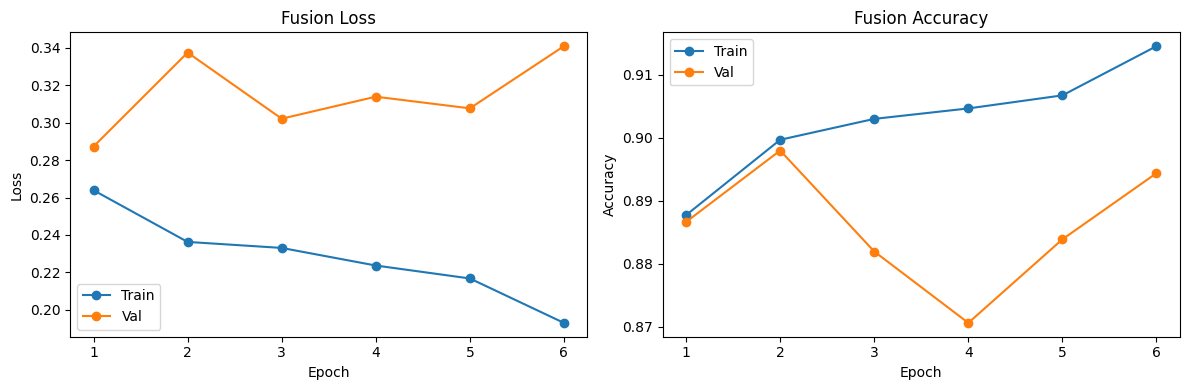

In [8]:
epochs_ran = np.arange(1, len(train_loss_hist) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Loss curves
ax[0].plot(epochs_ran, train_loss_hist, marker='o', label='Train')
ax[0].plot(epochs_ran, val_loss_hist,   marker='o', label='Val')
ax[0].set_title('Fusion Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy curves
ax[1].plot(epochs_ran, train_acc_hist, marker='o', label='Train')
ax[1].plot(epochs_ran, val_acc_hist,   marker='o', label='Val')
ax[1].set_title('Fusion Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()

plt.tight_layout()
plt.show()

### Evaluation on best checkpoint


--- ULTIMATE MULTIMODAL FUSION VALIDATION RESULTS ---
Val Accuracy:    89.80%
Val F1 (binary): 0.9321
Val F1 (macro):  0.8636
Val ROC-AUC:     0.9491


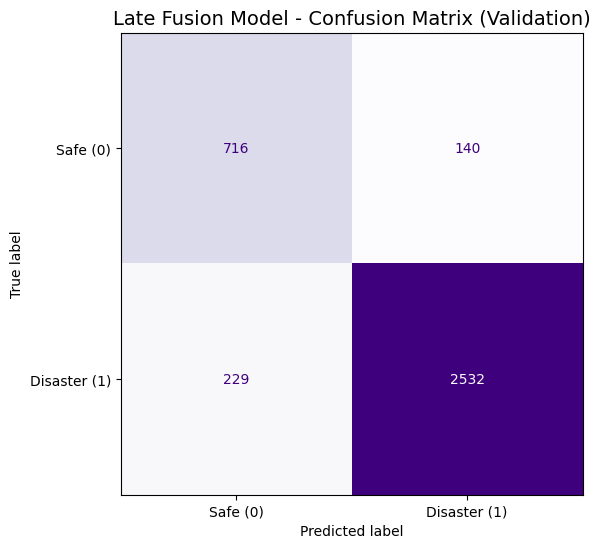

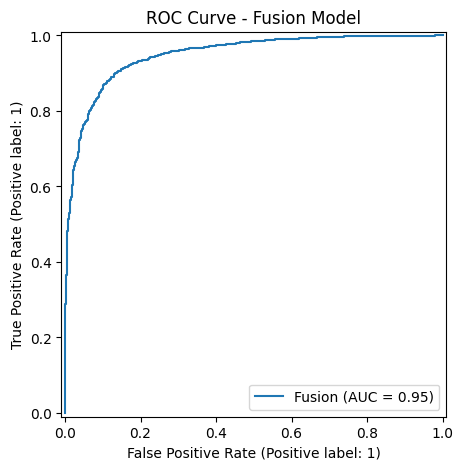

In [9]:
# model.load_state_dict(torch.load('../checkpoints/fusion_brain.pth', map_location=device))
model.load_state_dict(torch.load(str(FUSION_CKPT), map_location=device))

val_loss, val_acc, val_preds, val_true, val_probs = evaluate(
    model=model, loader=val_loader, criterion=criterion, device=device,
)

val_f1_macro  = f1_score(val_true, val_preds, average='macro')
val_f1_binary = f1_score(val_true, val_preds, average='binary')
val_roc_auc   = roc_auc_score(val_true, val_probs[:, 1])

print('\n--- ULTIMATE MULTIMODAL FUSION VALIDATION RESULTS ---')
print(f'Val Accuracy:    {val_acc * 100:.2f}%')
print(f'Val F1 (binary): {val_f1_binary:.4f}')
print(f'Val F1 (macro):  {val_f1_macro:.4f}')
print(f'Val ROC-AUC:     {val_roc_auc:.4f}')

cm = confusion_matrix(val_true, val_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Safe (0)', 'Disaster (1)'])
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Purples', ax=ax, colorbar=False)
plt.title('Late Fusion Model - Confusion Matrix (Validation)', fontsize=14)
plt.grid(False)
plt.show()

fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(val_true, val_probs[:, 1], ax=ax, name='Fusion')
ax.set_title('ROC Curve - Fusion Model')
plt.show()